# Industrial Machines Design -- Image Generation & Editing

This notebook generates images of trains (or other industrial machines) from text prompts
using **Stable Diffusion XL**, then lets you iteratively edit the style, color, and texture
using **img2img** and **InstructPix2Pix** -- all within Google Colab free-tier limits (T4 GPU).

**Workflow:**
1. Generate an image from a text prompt (SDXL)
2. Edit the image with a new style prompt (SDXL img2img) **or**
3. Edit the image with a plain-English instruction (InstructPix2Pix)

## 1. Setup & Install Dependencies

In [1]:
!pip install -q diffusers transformers accelerate safetensors torch Pillow ipywidgets
!nvidia-smi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 34.5 MB/s eta 0:00:00
Tue Feb 17 15:57:39 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   54C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                    

## 2. Imports & Helpers

In [2]:
import torch
from diffusers import (
    StableDiffusionXLPipeline,
    StableDiffusionXLImg2ImgPipeline,
    StableDiffusionInstructPix2PixPipeline,
    EulerAncestralDiscreteScheduler,
)
from PIL import Image
from IPython.display import display
import matplotlib.pyplot as plt
import gc, os


def show_images(images, titles=None, cols=2, figsize=(14, 7)):
    """Display one or more PIL images side-by-side with optional titles."""
    rows = (len(images) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    if not isinstance(axes, list):
        axes = axes.flatten() if hasattr(axes, "flatten") else [axes]
    for i, img in enumerate(images):
        axes[i].imshow(img)
        axes[i].axis("off")
        if titles:
            axes[i].set_title(titles[i], fontsize=11)
    for j in range(len(images), len(axes)):
        axes[j].axis("off")
    plt.tight_layout()
    plt.show()


def free_vram(*pipelines):
    """Delete pipeline objects and free GPU memory."""
    for p in pipelines:
        del p
    gc.collect()
    torch.cuda.empty_cache()
    print(f"VRAM freed. Allocated: {torch.cuda.memory_allocated() / 1e9:.2f} GB")

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


## 3. Load Stable Diffusion XL Pipeline

This loads the SDXL base model in float16 with memory optimizations for the T4 GPU.
We skip the refiner to stay comfortably within the 15 GB VRAM budget.

In [3]:
MODEL_ID = "stabilityai/stable-diffusion-xl-base-1.0"

pipe = StableDiffusionXLPipeline.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float16,
    variant="fp16",
    use_safetensors=True,
)
pipe.to("cuda")

pipe.enable_attention_slicing()
pipe.enable_vae_slicing()

print(f"Model loaded. VRAM allocated: {torch.cuda.memory_allocated() / 1e9:.2f} GB")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/609 [00:00<?, ?B/s]

Fetching 19 files:   0%|          | 0/19 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Model loaded. VRAM allocated: 7.05 GB


/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/pipeline_utils.py:2186: FutureWarning: `enable_vae_slicing` is deprecated and will be removed in version 0.40.0. Calling `enable_vae_slicing()` on a `StableDiffusionXLPipeline` is deprecated and this method will be removed in a future version. Please use `pipe.vae.enable_slicing()`.
  deprecate(


## 4. Generate a Train Image

Edit the `prompt` below to describe the train (or any industrial machine) you want.
The negative prompt helps avoid common artifacts.

  0%|          | 0/30 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/stable_diffusion_xl/pipeline_stable_diffusion_xl.py:748: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(


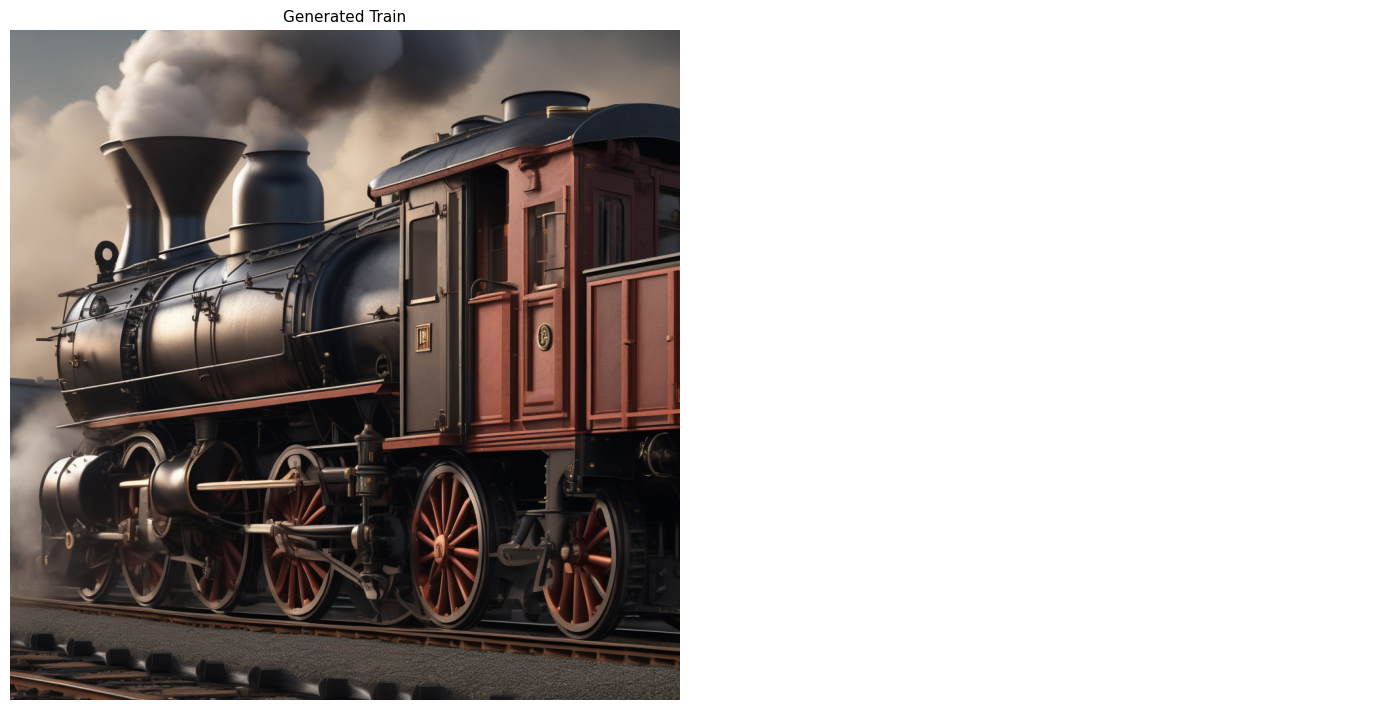

In [4]:
# ---- Edit your prompt here ----
prompt = (
    "A detailed industrial steam train, side view, "
    "high-detail engineering illustration, dramatic lighting, "
    "photorealistic, 4k, sharp focus"
)

negative_prompt = (
    "blurry, low quality, distorted, watermark, text, "
    "oversaturated, cartoon, anime, sketch, out of frame"
)

SEED = 42  # set to None for random results each time
# --------------------------------

generator = torch.Generator("cuda").manual_seed(SEED) if SEED is not None else None

generated_image = pipe(
    prompt=prompt,
    negative_prompt=negative_prompt,
    num_inference_steps=30,
    guidance_scale=7.5,
    height=1024,
    width=1024,
    generator=generator,
).images[0]

generated_image.save("/content/generated_train.png")
show_images([generated_image], titles=["Generated Train"])

## 5. Edit Image with SDXL img2img (Option A)

This reuses the **same SDXL model** (no extra download) to re-render the generated image
with a different style prompt. Adjust `strength` (0.0 = keep original, 1.0 = ignore original)
and swap in one of the preset prompts -- or write your own.

**Preset examples:**
- *Metallic chrome*: `"A metallic chrome train, reflective silver surface, industrial design, photorealistic"`
- *Grayscale/blueprint*: `"A monochrome grayscale train, no color, technical pencil sketch, engineering blueprint"`
- *Kids constructor*: `"A train made of colorful plastic building blocks, LEGO style, toy, bright colors, fun"`

In [5]:
# Build the img2img pipeline from the same model components (no extra VRAM)
img2img_pipe = StableDiffusionXLImg2ImgPipeline(
    vae=pipe.vae,
    text_encoder=pipe.text_encoder,
    text_encoder_2=pipe.text_encoder_2,
    tokenizer=pipe.tokenizer,
    tokenizer_2=pipe.tokenizer_2,
    unet=pipe.unet,
    scheduler=pipe.scheduler,
)
img2img_pipe.enable_attention_slicing()
img2img_pipe.enable_vae_slicing()

print("img2img pipeline ready (shared weights, no extra VRAM).")

img2img pipeline ready (shared weights, no extra VRAM).


/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/pipeline_utils.py:2186: FutureWarning: `enable_vae_slicing` is deprecated and will be removed in version 0.40.0. Calling `enable_vae_slicing()` on a `StableDiffusionXLImg2ImgPipeline` is deprecated and this method will be removed in a future version. Please use `pipe.vae.enable_slicing()`.
  deprecate(


  0%|          | 0/21 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/stable_diffusion_xl/pipeline_stable_diffusion_xl_img2img.py:896: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(


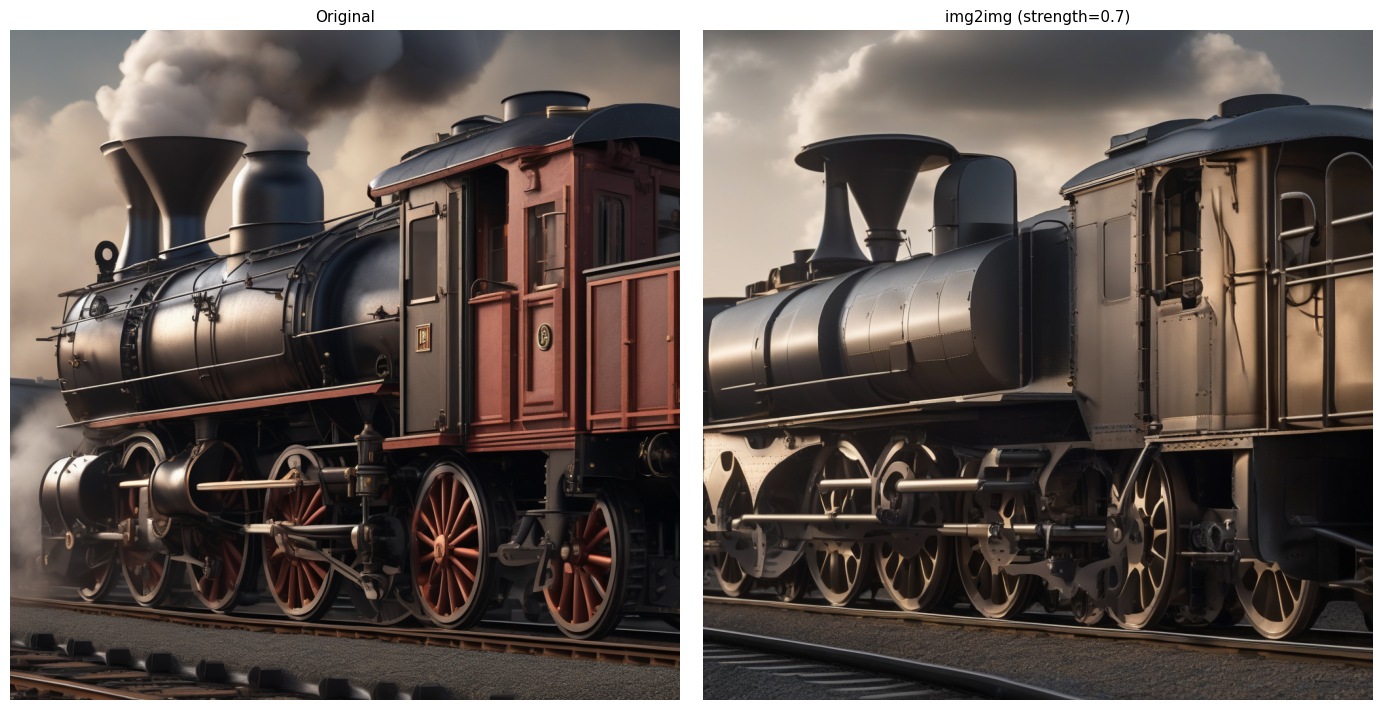

In [6]:
# ---- Choose / edit your style prompt and strength ----
edit_prompt = (
    "A train prototype made of raw brushed sheet metal, unpainted bare aluminum "
    "and steel surfaces, visible welding seams, rivets, matte metallic finish, "
    "no paint, no color, industrial metal prototype, studio lighting, 4k"
)

edit_negative_prompt = (
    "painted, colorful, wooden, plastic, blurry, low quality, "
    "distorted, watermark, text, cartoon, anime"
)

strength = 0.70  # 0.0 = keep original, 1.0 = ignore original completely
# -------------------------------------------------------

source_image = generated_image.resize((1024, 1024))

edited_image = img2img_pipe(
    prompt=edit_prompt,
    negative_prompt=edit_negative_prompt,
    image=source_image,
    strength=strength,
    num_inference_steps=30,
    guidance_scale=7.5,
    generator=torch.Generator("cuda").manual_seed(SEED) if SEED is not None else None,
).images[0]

edited_image.save("/content/edited_train_img2img.png")
show_images(
    [generated_image, edited_image],
    titles=["Original", f"img2img (strength={strength})"],
)

## 6. Edit Image with InstructPix2Pix (Option B)

**InstructPix2Pix** accepts a plain-English editing instruction instead of a full prompt.
It is a separate, lightweight model (~1.5 GB). We first free the SDXL model from VRAM,
then load InstructPix2Pix.

**Example instructions:**
- `"Make it look like shiny brushed metal"`
- `"Remove all color, make it grayscale"`
- `"Make it look like a kids building-block toy"`
- `"Add rust and weathering to the surface"`

In [7]:
# Free SDXL from GPU memory before loading InstructPix2Pix
free_vram(pipe, img2img_pipe)

VRAM freed. Allocated: 7.06 GB


In [8]:
PIX2PIX_MODEL = "timbrooks/instruct-pix2pix"

pix2pix_pipe = StableDiffusionInstructPix2PixPipeline.from_pretrained(
    PIX2PIX_MODEL,
    torch_dtype=torch.float16,
    safety_checker=None,
)
pix2pix_pipe.to("cuda")
pix2pix_pipe.scheduler = EulerAncestralDiscreteScheduler.from_config(
    pix2pix_pipe.scheduler.config
)

print(f"InstructPix2Pix loaded. VRAM: {torch.cuda.memory_allocated() / 1e9:.2f} GB")

model_index.json:   0%|          | 0.00/616 [00:00<?, ?B/s]

Fetching 13 files:   0%|          | 0/13 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--timbrooks--instruct-pix2pix/snapshots/31519b5cb02a7fd89b906d88731cd4d6a7bbf88d/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


InstructPix2Pix loaded. VRAM: 9.22 GB


  0%|          | 0/25 [00:00<?, ?it/s]

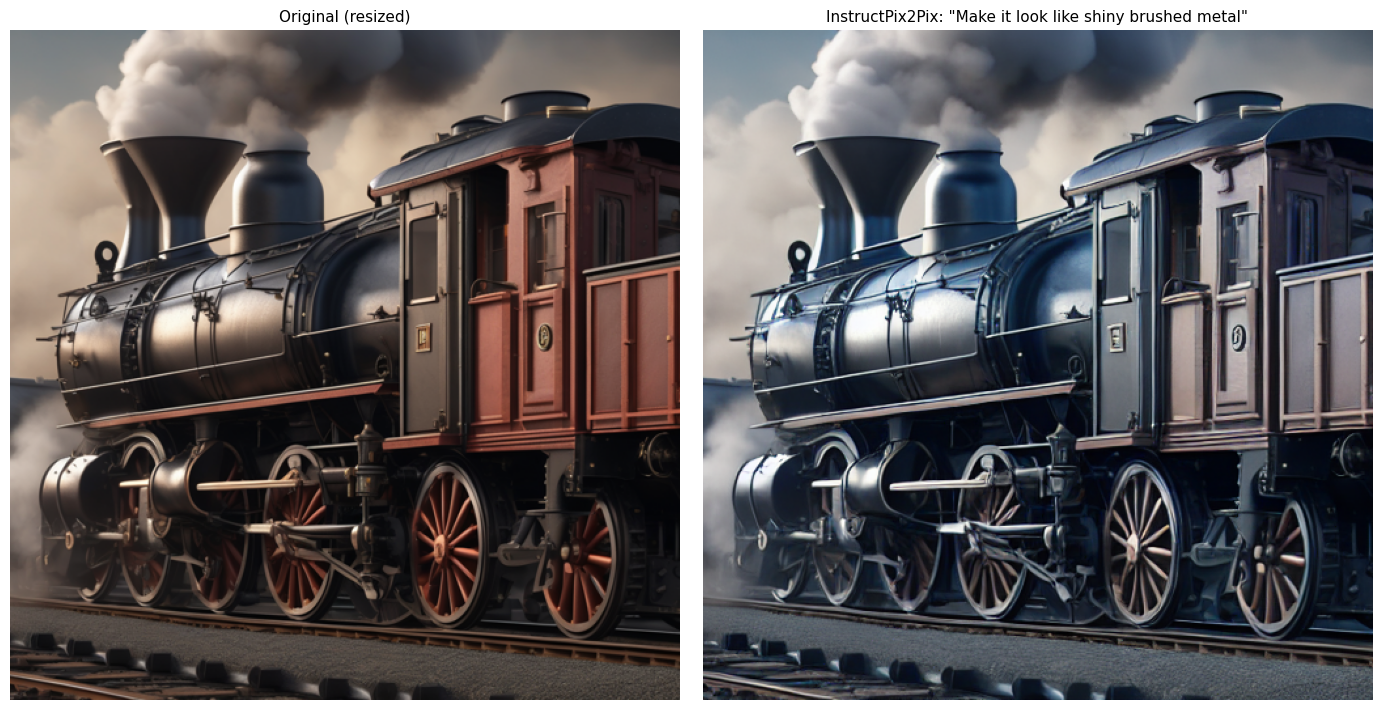

In [9]:
# ---- Edit your instruction here ----
instruction = "Make it look like shiny brushed metal"

# image_guidance_scale: how closely to follow the original image (higher = closer)
# guidance_scale: how closely to follow the text instruction (higher = stronger edit)
image_guidance_scale = 1.5
guidance_scale = 7.0
# -------------------------------------

source = Image.open("/content/generated_train.png").resize((512, 512))

pix2pix_result = pix2pix_pipe(
    prompt=instruction,
    image=source,
    num_inference_steps=25,
    image_guidance_scale=image_guidance_scale,
    guidance_scale=guidance_scale,
).images[0]

pix2pix_result.save("/content/edited_train_pix2pix.png")
show_images(
    [source, pix2pix_result],
    titles=["Original (resized)", f'InstructPix2Pix: "{instruction}"'],
)

## 6b. Remove Background

Use `rembg` to cleanly cut out just the train from any image (works on both the img2img and InstructPix2Pix results). This is a separate segmentation model -- it does not alter the train itself.

In [10]:
!pip install -q rembg onnxruntime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 85.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 108.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.9/54.9 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 33.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 94.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 78.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 15.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.19.0 requires numpy<2.2.0,>=1.26.0, but you have numpy 2.3.5 which is incompatible.
cudf-cu12 25.10.0 req

  0%|                                               | 0.00/176M [00:00<?, ?B/s]

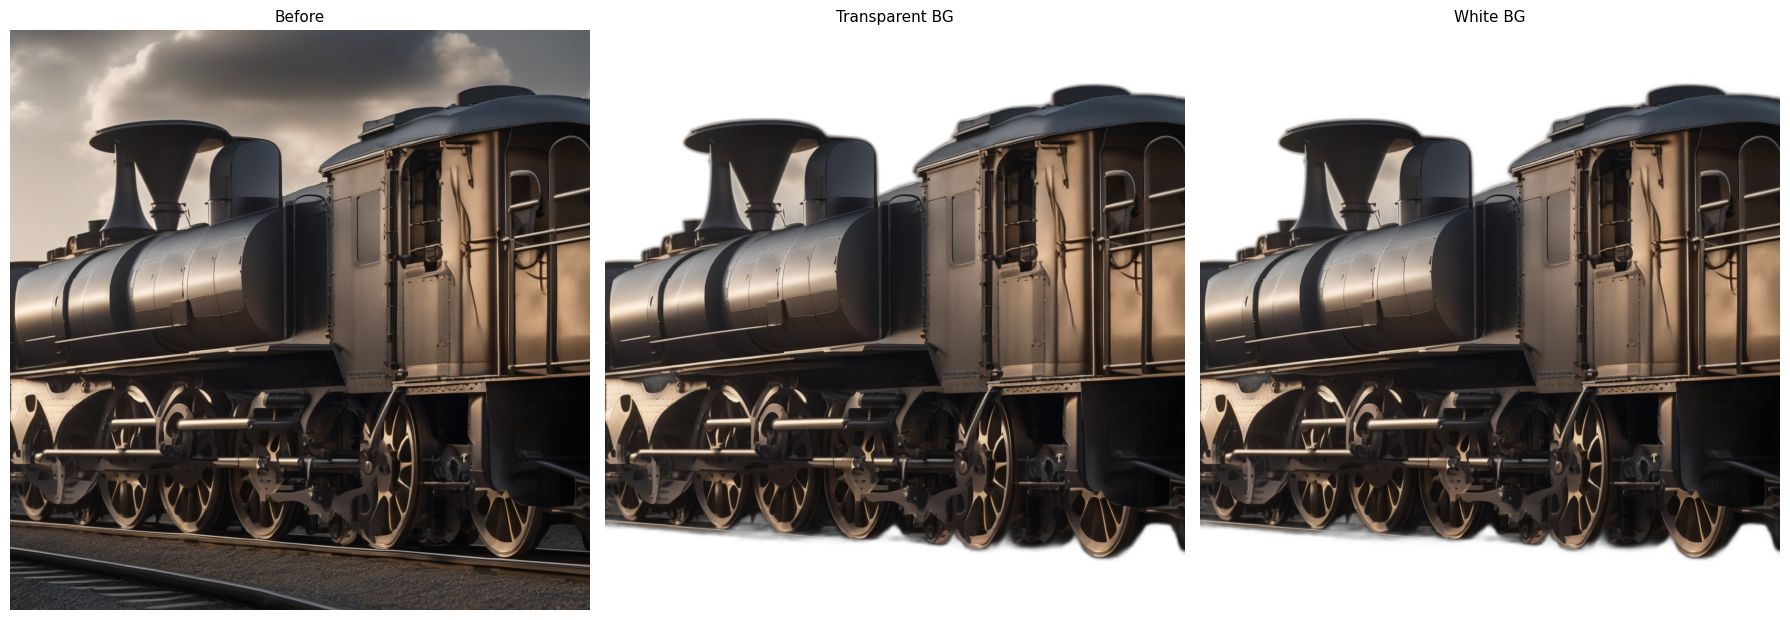

In [11]:
from rembg import remove

# Load whichever edited image you want to cut out
input_image = Image.open("/content/edited_train_img2img.png")

# Remove background (returns RGBA with transparent background)
no_bg = remove(input_image)
no_bg.save("/content/train_no_bg.png")

# Version with white background instead of transparent
white_bg = Image.new("RGBA", no_bg.size, (255, 255, 255, 255))
white_bg.paste(no_bg, mask=no_bg.split()[3])
final = white_bg.convert("RGB")
final.save("/content/train_white_bg.png")

show_images(
    [input_image, no_bg, final],
    titles=["Before", "Transparent BG", "White BG"],
    cols=3,
    figsize=(18, 7),
)

## 8. Save & Download Results

Run the cell below to download all generated/edited images to your local machine.

In [12]:
from google.colab import files

output_dir = "/content"
saved_files = [
    f for f in os.listdir(output_dir)
    if f.endswith(".png") and ("train" in f or "edited" in f)
]

print("Images available for download:")
for fname in sorted(saved_files):
    fpath = os.path.join(output_dir, fname)
    size_kb = os.path.getsize(fpath) / 1024
    print(f"  {fname}  ({size_kb:.0f} KB)")
    files.download(fpath)

print("\nDone! Check your browser downloads.")

Images available for download:
  edited_train_img2img.png  (1453 KB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  edited_train_pix2pix.png  (425 KB)


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

  train_white_bg.png  (1067 KB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Done! Check your browser downloads.
